In [1]:
import numpy as np
import pandas as pd

In [2]:
fold0 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold0_-0.5_all_data_extra.tsv", sep="\t")

In [3]:
fold0["fold"] = [0 for i in range(len(fold0))]

In [4]:
fold1 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold1_-0.5_all_data_extra.tsv", sep="\t")

In [5]:
fold1["fold"] = [1 for i in range(len(fold1))]

In [6]:
fold2 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold2_-0.5_all_data_extra.tsv", sep="\t")

In [7]:
fold2["fold"] = [2 for i in range(len(fold2))]

In [8]:
df = pd.concat([fold0, fold1, fold2], ignore_index=True)

In [9]:
len(df)

164

In [10]:
df.head()

,chrom,start_query,end_query,centered_start,centered_end,last_accepted_step_query,flat_start_query,flat_end_query,active_count,neutral_count,...,GC_slice,GC_slice_edited,flat_GC_content,init_CTCFs_num,CTCFs_num,FIMO_sum,FIMO_max,orientation,positions,fold
0,chr1,38324224,38586368,37799936,39110656,1554,195.0,323.0,9.0,12.0,...,0.459961,0.524414,0.414062,0,6,116.884754,23.597869,++----,"[(1661, 1680), (1793, 1812), (187, 206), (251,...",0
1,chr11,66207744,66457600,65677312,66988032,804,76.0,199.0,5.0,8.0,...,0.422852,0.460449,0.409836,1,6,98.783829,25.030489,++++--,"[(223, 242), (289, 308), (480, 499), (1527, 15...",0
2,chr3,38950912,39409664,38524928,39835648,1703,198.0,422.0,15.0,16.0,...,0.437988,0.449707,0.517857,0,4,65.972716,22.499068,++++,"[(278, 297), (337, 356), (422, 441), (1932, 19...",0
3,chr3,41277440,41482240,40724480,42035200,948,82.0,182.0,5.0,10.0,...,0.418945,0.403809,0.450000,0,7,109.634081,23.450102,+++++--,"[(406, 425), (890, 909), (944, 963), (2048, 20...",0
4,chr3,52432896,52776960,51949568,53260288,878,247.0,416.0,18.0,21.0,...,0.479492,0.542969,0.482143,1,4,84.435493,25.464185,++--,"[(456, 475), (1309, 1328), (376, 395), (1234, ...",0


In [11]:
df['optimization_successful'] = df['SCD'] > 50

In [12]:
df[df["SCD"] < 50]

,chrom,start_query,end_query,centered_start,centered_end,last_accepted_step_query,flat_start_query,flat_end_query,active_count,neutral_count,...,GC_slice_edited,flat_GC_content,init_CTCFs_num,CTCFs_num,FIMO_sum,FIMO_max,orientation,positions,fold,optimization_successful
18,chr4,95569920,95807488,95033344,96344064,757,92.0,209.0,3.0,5.0,...,0.365723,0.284483,0,0,0.0,0.0,no,(),0,False
73,chr1,185933824,186204160,185413632,186724352,460,323.0,455.0,10.0,13.0,...,0.411621,0.477273,0,0,0.0,0.0,no,(),1,False
106,chr11,40241152,40503296,39716864,41027584,387,250.0,379.0,4.0,5.0,...,0.349609,0.429688,0,0,0.0,0.0,no,(),2,False
129,chr16,83890176,84422656,83501056,84811776,589,56.0,317.0,8.0,10.0,...,0.411621,0.384615,0,0,0.0,0.0,no,(),2,False


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

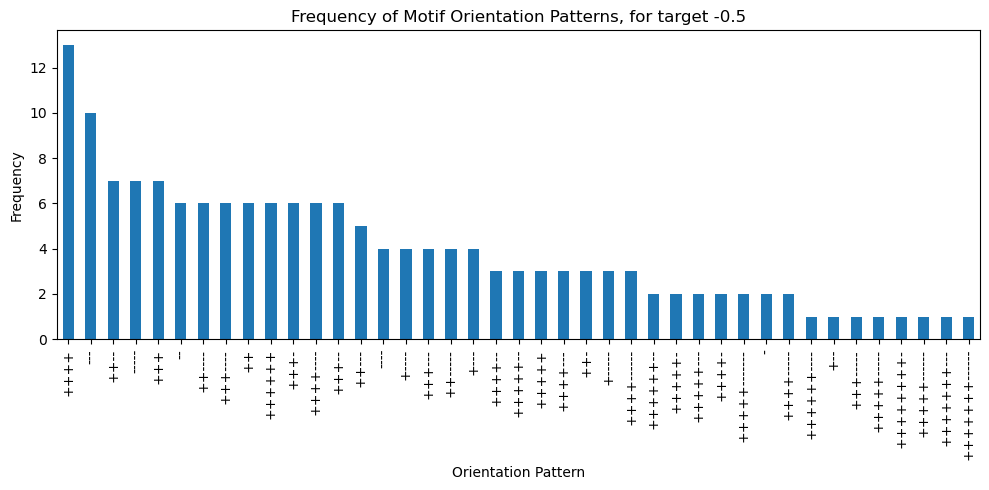

In [14]:
orientation_counts = df[df['orientation'] != "no"]['orientation'].value_counts()

# Plot
plt.figure(figsize=(10, 5))
orientation_counts.plot(kind='bar')
plt.xlabel("Orientation Pattern")
plt.ylabel("Frequency")
plt.title("Frequency of Motif Orientation Patterns, for target -0.5")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [15]:
df_melted = df.melt(value_vars=['URQ_result', 'URQ_target'], var_name='Type', value_name='URQ mean')

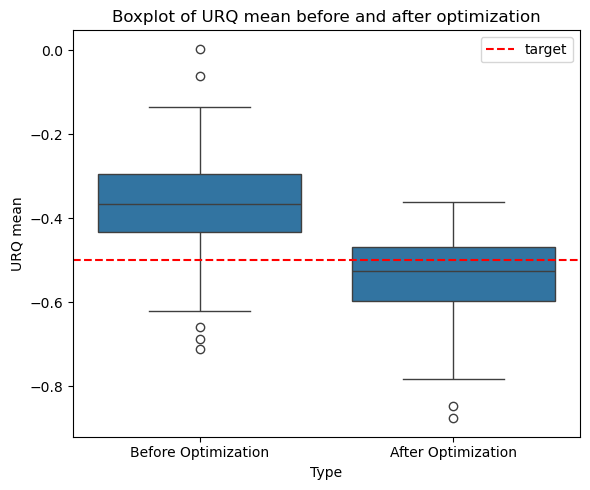

In [16]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Type', y='URQ mean', data=df_melted)
plt.axhline(y=-0.5, color='red', linestyle='--', linewidth=1.5, label='target')
plt.xticks([0, 1], ['Before Optimization', 'After Optimization'])
plt.title('Boxplot of URQ mean before and after optimization')
plt.legend()
plt.tight_layout()
plt.show()

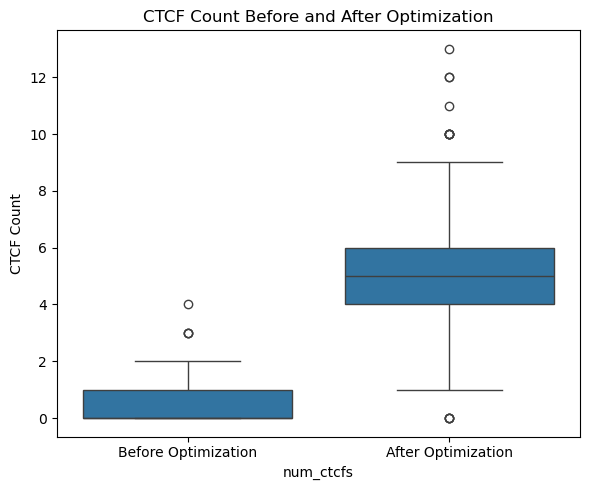

In [17]:
df_box_melted = df.melt(value_vars=['init_CTCFs_num', 'CTCFs_num'],
                            var_name='num_ctcfs', value_name='CTCF Count')

# Rename the categories for clarity
label_map = {
    'init_CTCFs_num': 'Before Optimization',
    'CTCFs_num': 'After Optimization'
}
df_box_melted['num_ctcfs'] = df_box_melted['num_ctcfs'].map(label_map)

# Plotting
plt.figure(figsize=(6, 5))
sns.boxplot(x='num_ctcfs', y='CTCF Count', data=df_box_melted)
plt.title('CTCF Count Before and After Optimization')
plt.tight_layout()
plt.show()

In [18]:
from scipy.stats import pearsonr

In [19]:
# Calculate Pearson correlation coefficient
r_value, p_value = pearsonr(df['URQ_target'], df['URQ_result'])

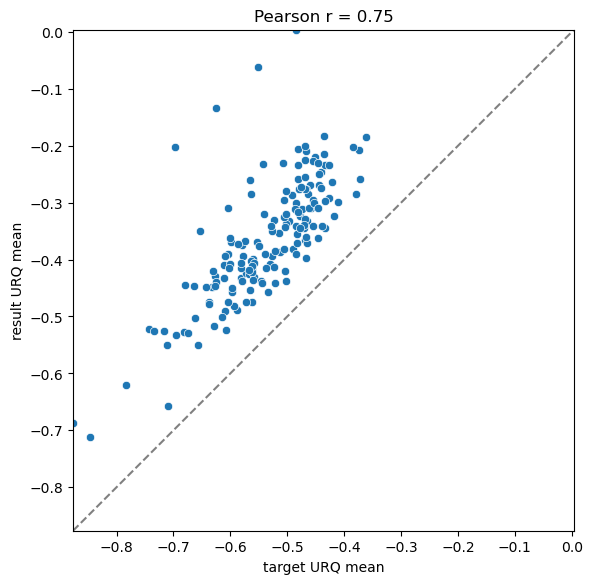

In [20]:
# Determine shared range for both axes
min_val = min(df['URQ_target'].min(), df['URQ_result'].min())
max_val = max(df['URQ_target'].max(), df['URQ_result'].max())

# Plotting the scatterplot with equal axis limits and square aspect ratio
plt.figure(figsize=(6, 6))
sns.scatterplot(x='URQ_target', y='URQ_result', data=df)
plt.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--')  # reference diagonal
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.gca().set_aspect('equal', adjustable='box')
plt.title(f'Pearson r = {r_value:.2f}')
plt.xlabel('target URQ mean')
plt.ylabel('result URQ mean')
plt.tight_layout()
plt.show()


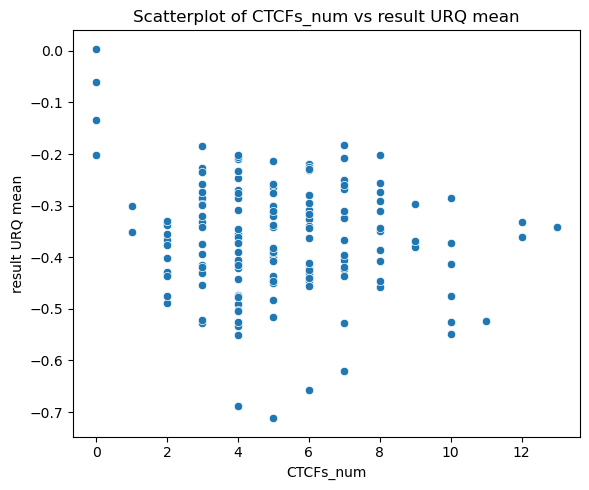

In [21]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x='CTCFs_num', y='URQ_result', data=df)
plt.xlabel('CTCFs_num')
plt.ylabel('result URQ mean')
plt.title('Scatterplot of CTCFs_num vs result URQ mean')
plt.tight_layout()
plt.show()

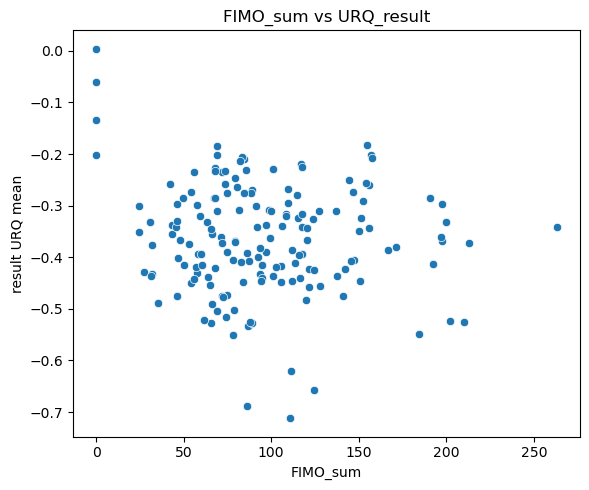

In [22]:
# Plotting the scatterplot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='FIMO_sum', y='URQ_result', data=df)
plt.xlabel('FIMO_sum')
plt.ylabel('result URQ mean')
plt.title(f'FIMO_sum vs URQ_result')
plt.tight_layout()
plt.show()

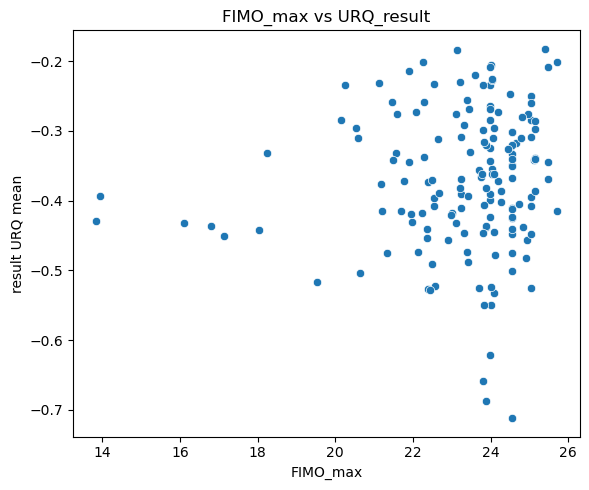

In [23]:
# Plotting the scatterplot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='FIMO_max', y='URQ_result', data=df[df["SCD"] > 50])
plt.xlabel('FIMO_max')
plt.ylabel('result URQ mean')
plt.title(f'FIMO_max vs URQ_result')
plt.tight_layout()
plt.show()

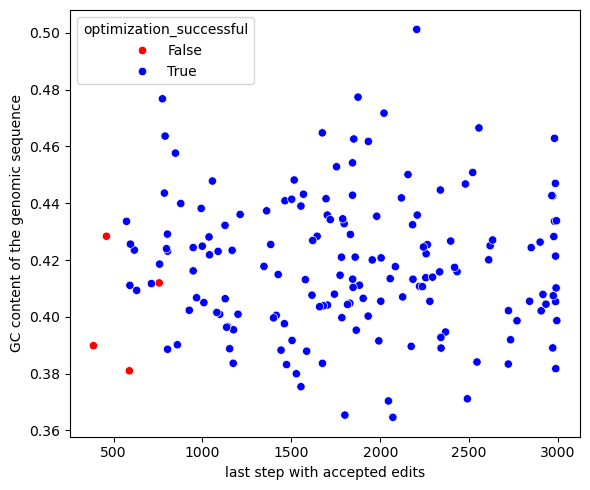

In [24]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='last_accepted_step_query',
    y='GC_seq',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('last step with accepted edits')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

In [26]:
df.columns

Index(['chrom', 'start_query', 'end_query', 'centered_start', 'centered_end',
       'last_accepted_step_query', 'flat_start_query', 'flat_end_query',
       'active_count', 'neutral_count', 'repressive_count', 'total',
       'active_fraction', 'neutral_fraction', 'repressive_fraction',
       'flat_length', 'SCD', 'URQ_result', 'URQ_target', 'URQ_init',
       'num_edits', 'GC_seq', 'GC_slice', 'GC_slice_edited', 'flat_GC_content',
       'init_CTCFs_num', 'CTCFs_num', 'FIMO_sum', 'FIMO_max', 'orientation',
       'positions', 'fold', 'optimization_successful'],
      dtype='object')

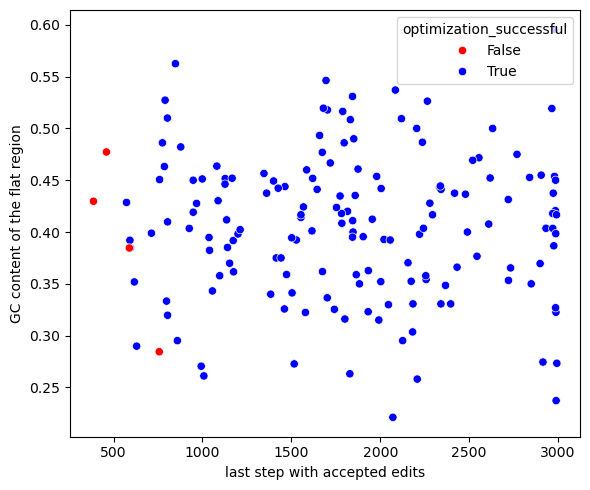

In [27]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='last_accepted_step_query',
    y='flat_GC_content',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('last step with accepted edits')
plt.ylabel('GC content of the flat region')
plt.tight_layout()
plt.show()

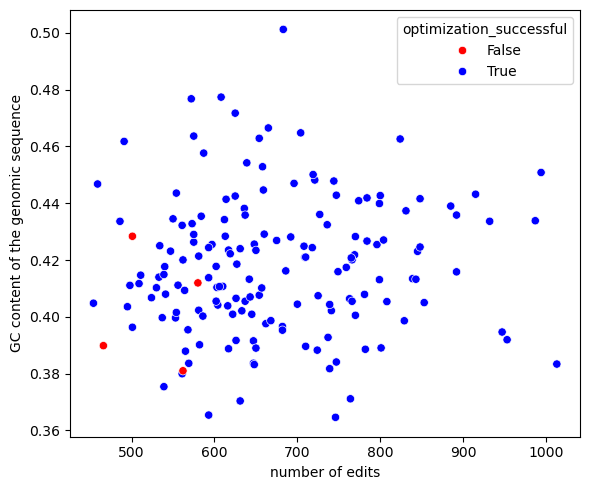

In [25]:
plt.figure(figsize=(6, 5))

sns.scatterplot(
    x='num_edits',
    y='GC_seq',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)

plt.xlabel('number of edits')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

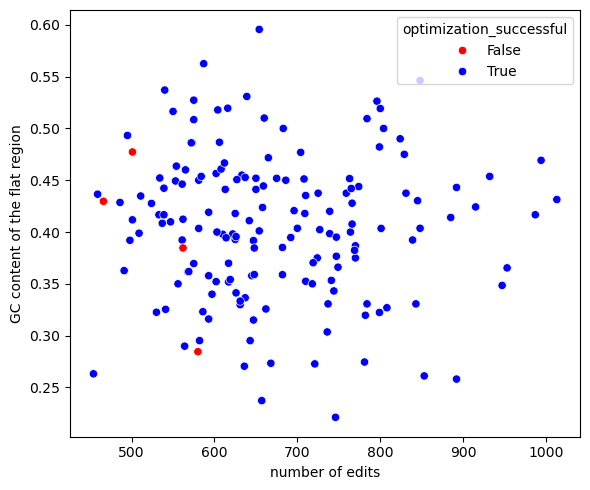

In [29]:
plt.figure(figsize=(6, 5))

sns.scatterplot(
    x='num_edits',
    y='flat_GC_content',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)

plt.xlabel('number of edits')
plt.ylabel('GC content of the flat region')
plt.tight_layout()
plt.show()

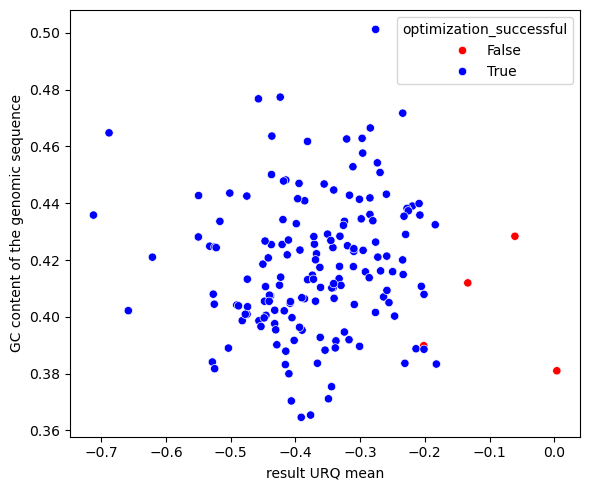

In [30]:
plt.figure(figsize=(6, 5))

sns.scatterplot(
    x='URQ_result',
    y='GC_seq',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)

plt.xlabel('result URQ mean')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

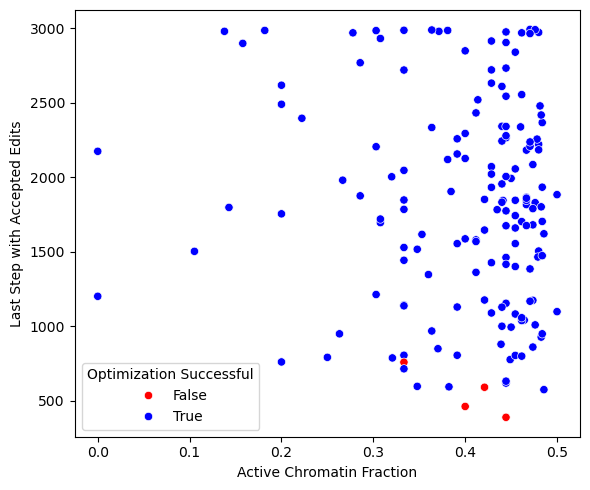

In [31]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='active_fraction',
    y='last_accepted_step_query',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Active Chromatin Fraction')
plt.ylabel('Last Step with Accepted Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()


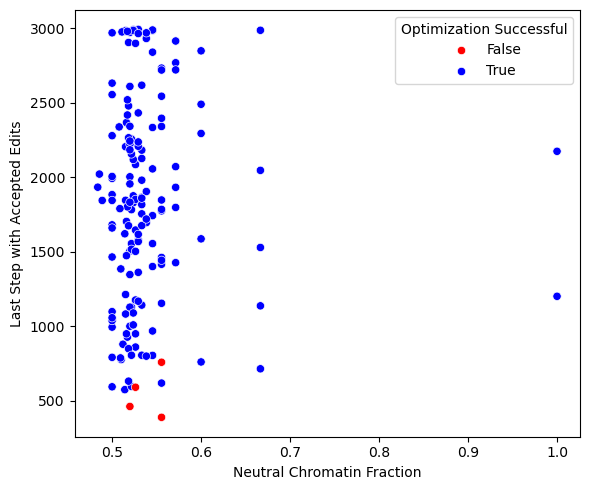

In [32]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='neutral_fraction',
    y='last_accepted_step_query',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Neutral Chromatin Fraction')
plt.ylabel('Last Step with Accepted Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

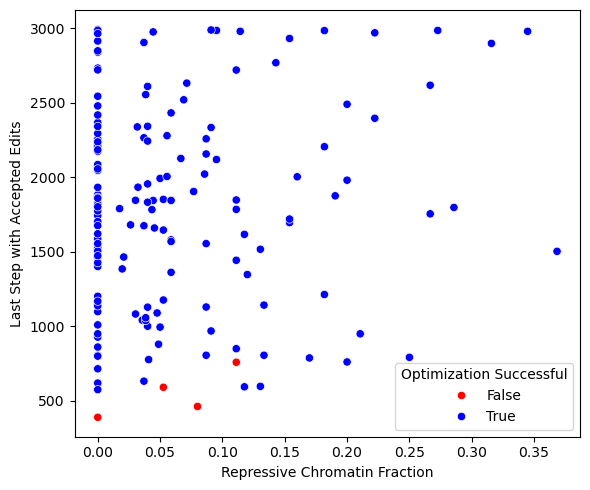

In [33]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='repressive_fraction',
    y='last_accepted_step_query',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Repressive Chromatin Fraction')
plt.ylabel('Last Step with Accepted Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

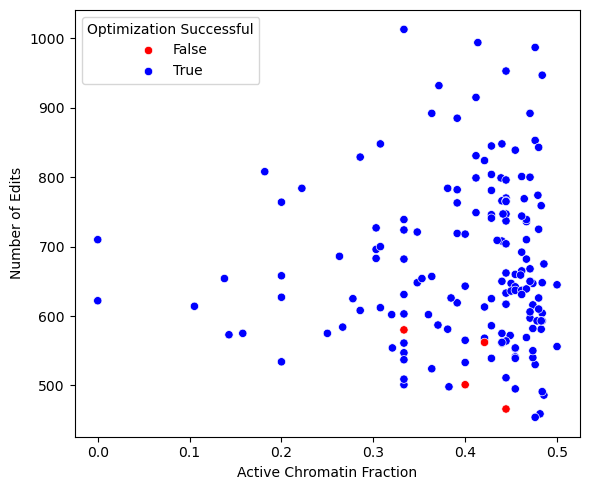

In [34]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='active_fraction',
    y='num_edits',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Active Chromatin Fraction')
plt.ylabel('Number of Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

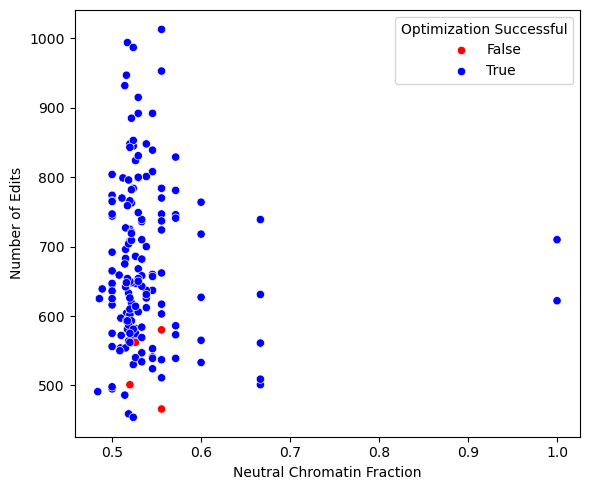

In [35]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='neutral_fraction',
    y='num_edits',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Neutral Chromatin Fraction')
plt.ylabel('Number of Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

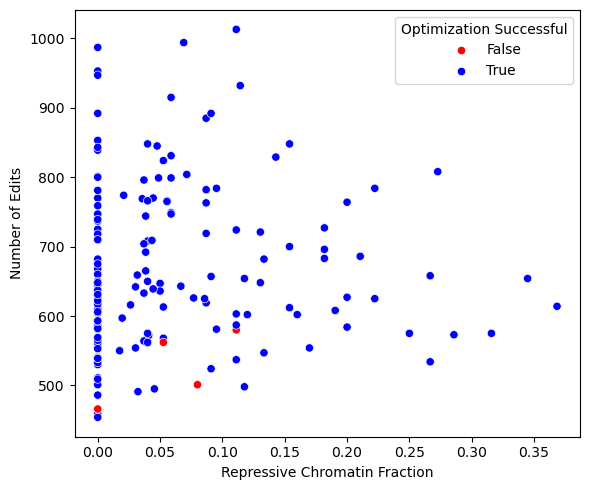

In [36]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='repressive_fraction',
    y='num_edits',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Repressive Chromatin Fraction')
plt.ylabel('Number of Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

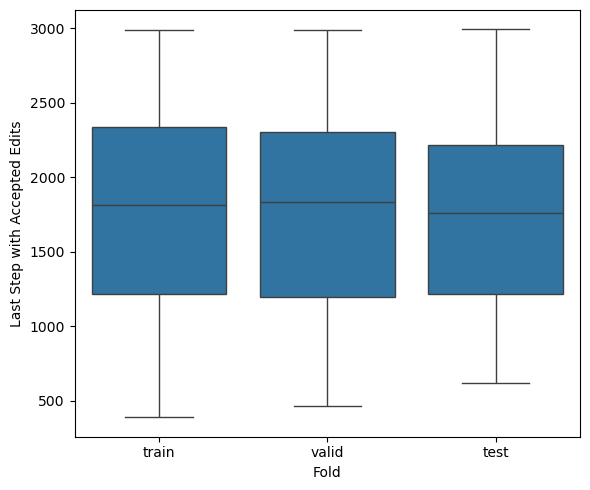

In [37]:
fold_map = {0: 'test', 1: 'valid', 2: 'train'}
df['set'] = df['fold'].map(fold_map)

# Plotting the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='set', y='last_accepted_step_query', data=df, order=['train', 'valid', 'test'])
plt.xlabel('Fold')
plt.ylabel('Last Step with Accepted Edits')
plt.tight_layout()
plt.show()

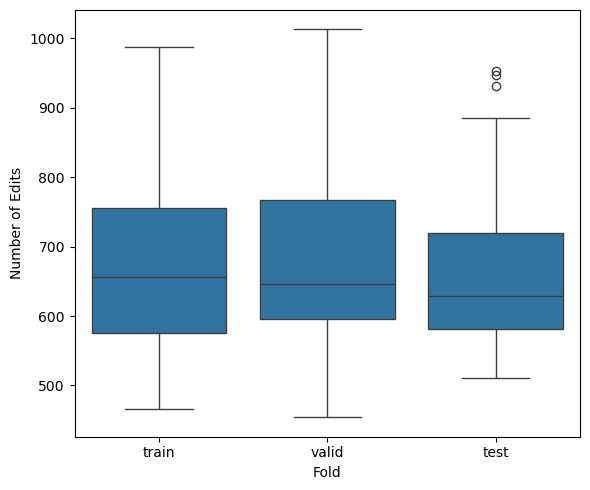

In [38]:
# Plotting the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='set', y='num_edits', data=df, order=['train', 'valid', 'test'])
plt.xlabel('Fold')
plt.ylabel('Number of Edits')
plt.tight_layout()
plt.show()

In [39]:
from scipy.stats import ttest_rel

In [40]:
t_stat, p_val = ttest_rel(df['GC_slice'], df['GC_slice_edited'])

In [41]:
t_stat, p_val

(-10.628345779363114, 2.2362829611236995e-20)

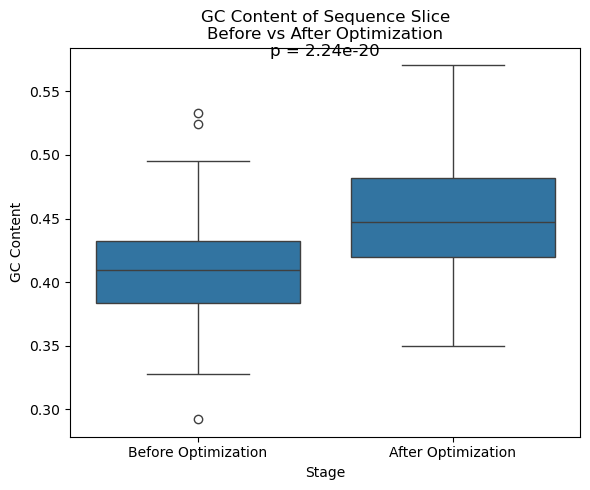

In [42]:
# Melt the DataFrame for plotting
df_gc_melted = df.melt(value_vars=['GC_slice', 'GC_slice_edited'],
                          var_name='Stage', value_name='GC Content')

# Rename the stages for clarity
stage_map = {
    'GC_slice': 'Before Optimization',
    'GC_slice_edited': 'After Optimization'
}
df_gc_melted['Stage'] = df_gc_melted['Stage'].map(stage_map)

# Plotting the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='Stage', y='GC Content', data=df_gc_melted)
plt.title('GC Content of Sequence Slice\nBefore vs After Optimization')
plt.text(0.5, max(df_gc_melted['GC Content']) + 0.005,
         f'p = {p_val:.3g}', ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
df.columns